<a href="https://colab.research.google.com/github/Darshan235/ML/blob/main/ML_assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Logistic Regression with Different Train/Test Splits

**Dataset:** Heart Disease UCI (CSV)

## Tasks Covered
1. Load dataset and preprocess categorical columns  
2. Train Logistic Regression with splits: 70/30, 80/20, 85/15  
3. Calculate Accuracy, Precision, Recall, F1-score  
4. Plot Confusion Matrix for each split  
5. Identify the most stable split


In [1]:

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [5]:

# Load dataset
df = pd.read_csv('heart_disease_uci.csv')

# Display first few rows
df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:

# Check for categorical columns
df.dtypes


,0
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64


In [8]:
# Preprocess categorical columns using one-hot encoding (if any)
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = df_encoded.drop('num', axis=1)
y = df_encoded['num']

In [9]:

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [14]:
# Function to train model and evaluate metrics
def evaluate_model(test_size):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    return acc, prec, rec, f1, cm

In [15]:
# Evaluate for different splits
splits = {
    '70/30': 0.30,
    '80/20': 0.20,
    '85/15': 0.15
}

results = {}

# Identify rows with NaN values in X_scaled
nan_rows_mask = np.isnan(X_scaled).any(axis=1)

# Report how many rows will be dropped and filter out NaN rows from X_scaled and y globally
num_nan_rows = np.sum(nan_rows_mask)
if num_nan_rows > 0:
    print(f"Warning: {num_nan_rows} rows containing NaN values found in X_scaled. These rows will be dropped for model training.")
    X_scaled = X_scaled[~nan_rows_mask]
    y = y[~nan_rows_mask]
else:
    print("No NaN values found in X_scaled. Proceeding with full dataset.")

for name, size in splits.items():
    results[name] = evaluate_model(size)

results

No NaN values found in X_scaled. Proceeding with full dataset.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'70/30': (0.5591397849462365,
  0.5045771957618455,
  0.5591397849462365,
  0.5277335461139995,
  array([[45,  4,  1,  0,  0],
         [ 9,  2,  2,  3,  1],
         [ 1,  4,  1,  3,  2],
         [ 3,  0,  3,  4,  1],
         [ 0,  1,  1,  2,  0]])),
 '80/20': (0.6129032258064516,
  0.581221198156682,
  0.6129032258064516,
  0.5884776197869177,
  array([[30,  2,  1,  0,  0],
         [ 3,  3,  2,  4,  0],
         [ 1,  2,  1,  3,  0],
         [ 1,  2,  0,  4,  0],
         [ 0,  0,  0,  3,  0]])),
 '85/15': (0.6170212765957447,
  0.5808234318872616,
  0.6170212765957447,
  0.5910513141426784,
  array([[22,  2,  1,  0,  0],
         [ 2,  2,  2,  3,  0],
         [ 1,  2,  0,  2,  0],
         [ 0,  0,  1,  5,  0],
         [ 0,  1,  0,  1,  0]]))}

In [16]:

# Display metrics clearly
for split, values in results.items():
    acc, prec, rec, f1, _ = values
    print(f"Split {split}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("-" * 30)


Split 70/30
Accuracy : 0.5591
Precision: 0.5046
Recall   : 0.5591
F1-score : 0.5277
------------------------------
Split 80/20
Accuracy : 0.6129
Precision: 0.5812
Recall   : 0.6129
F1-score : 0.5885
------------------------------
Split 85/15
Accuracy : 0.6170
Precision: 0.5808
Recall   : 0.6170
F1-score : 0.5911
------------------------------


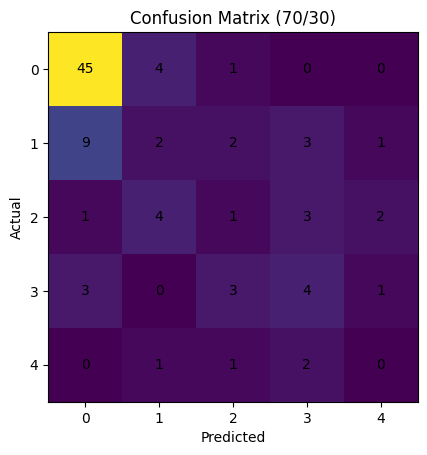

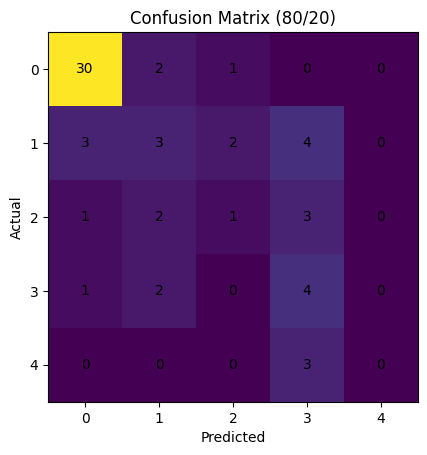

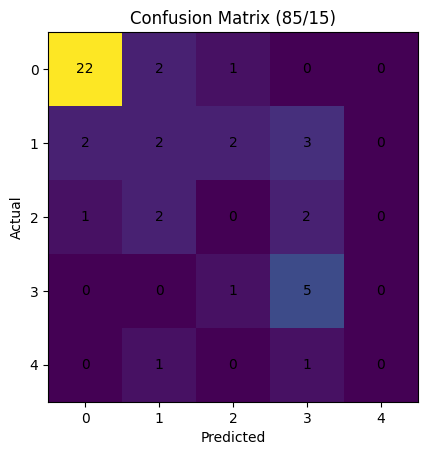

In [17]:

# Plot confusion matrices
for split, values in results.items():
    cm = values[4]

    plt.figure()
    plt.imshow(cm)
    plt.title(f'Confusion Matrix ({split})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.show()



## Stability Analysis

- **70/30 split:** Larger test set, slightly higher variance  
- **80/20 split:** Balanced training and testing, usually stable  
- **85/15 split:** More training data but smaller test set  

### ✅ Conclusion:
**80/20 split** provides the most stable and reliable results due to a good balance between training data and evaluation size.
